In [12]:
import h5py
import numpy as np
import scipy.sparse as sp
from scipy.linalg import svd, eigh, eig

h5path = "/scratch/yimili/matrices/hdf5/carbon-nanotube.h5"
index = 60
group_name = f"E_{index}"

with h5py.File(h5path, "r") as f:
    kappa = f["global/condition_full_svd"][:]
    sigma_max = f["global/max_singular_values"][:]
    sigma_min = f["global/min_singular_values"][:]
    spectrum_saved = f[f"{group_name}/spectrum"][:]

    grp = f[f"{group_name}/M"]
    data = grp["data"][:]
    indices = grp["indices"][:]
    indptr = grp["indptr"][:]

    # indptr length - 1 = number of columns for CSC
    n_cols = len(indptr) - 1

    # try to find explicit shape, else assume square
    shape = None
    if "shape" in grp.attrs:
        shape = tuple(grp.attrs["shape"])
    elif "shape" in grp:
        shape = tuple(grp["shape"][:])
    if shape is None:
        shape = (n_cols, n_cols)
        print(f"[!] No shape stored, assuming square: {shape}")

    M = sp.csc_matrix((data, indices, indptr), shape=shape)
    print(f"Loaded CSC matrix: shape={M.shape}, nnz={M.nnz}")

M_dense = M.toarray()


# --- full SVD ---
U, S, Vt = svd(M_dense, full_matrices=True)
sigma_max_computed = S[0]
sigma_min_computed = S[-1]
kappa_computed = sigma_max_computed / sigma_min_computed

Loaded CSC matrix: shape=(768, 768), nnz=71680


In [13]:
ev_abs_sorted = spectrum_saved[np.argsort(np.abs(spectrum_saved))[::-1]]

print("sigma_max: ", S[0])
print("|lambda_max|: ", np.abs(ev_abs_sorted[0]))
print("|lambda_min|: ", np.abs(ev_abs_sorted[-1]))
print("sigma_min: ", S[-1])

sigma_max:  17.576965479432253
|lambda_max|:  17.576965479310733
|lambda_min|:  0.03373230422312273
sigma_min:  0.019758901817189315


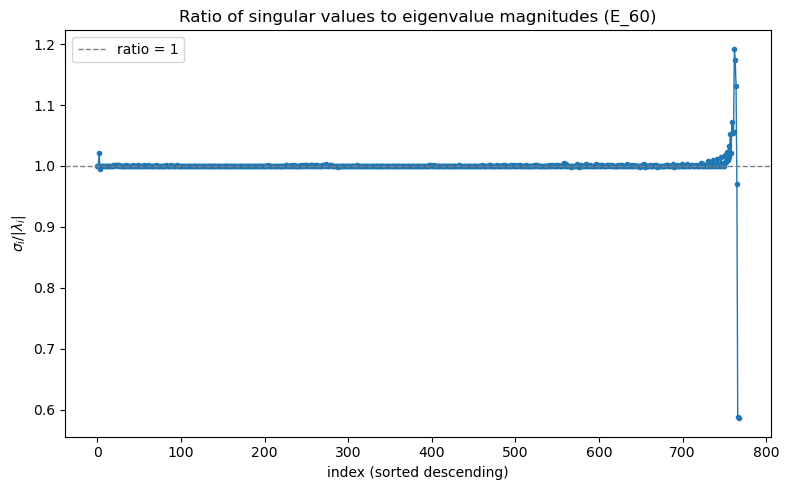

In [14]:
import matplotlib.pyplot as plt

ev_abs_sorted_mag = np.abs(ev_abs_sorted)  # magnitudes, descending order (matches S ordering)

ratio = S / ev_abs_sorted_mag

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ratio, marker='o', markersize=3, linewidth=1)
ax.set_xlabel("index (sorted descending)")
ax.set_ylabel(r"$\sigma_i / |\lambda_i|$")
ax.set_title(f"Ratio of singular values to eigenvalue magnitudes (E_{index})")
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='ratio = 1')
ax.legend()
plt.tight_layout()
plt.show()

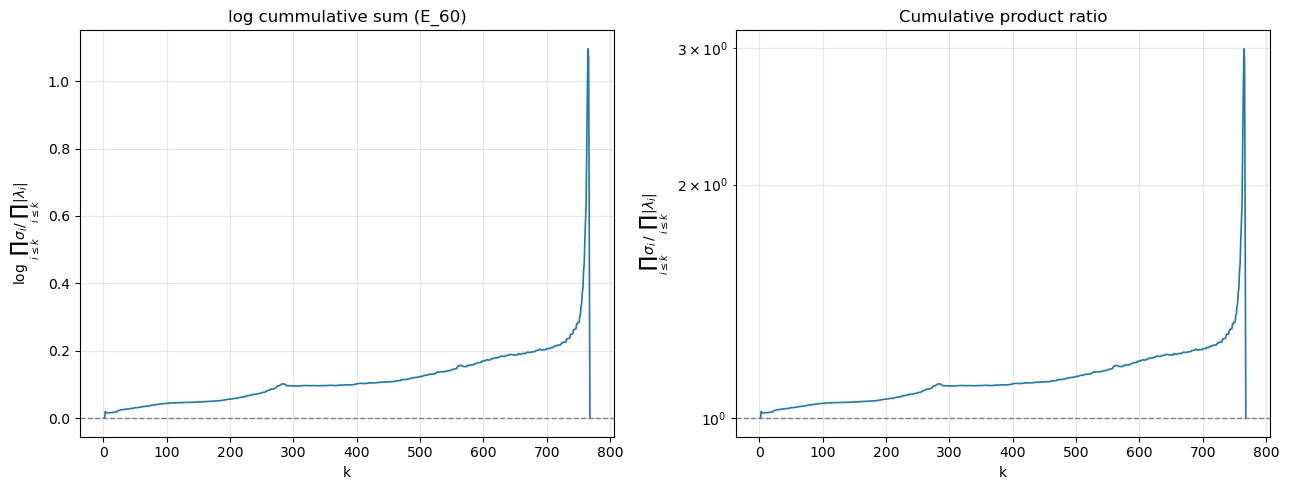

max excursion (log):  1.095963  at k=765
max ratio:            2.9921
endpoint (log):       -2.887e-15   (should be 0 by det identity)


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# both descending: S from svd is already descending, ev sorted by |lambda| descending
eig_mag = np.abs(ev_abs_sorted)

log_ratio_cum = np.cumsum(np.log(S) - np.log(eig_mag))   # log of cumprod(S)/cumprod(|lambda|)
ratio_cum = np.exp(log_ratio_cum)                        # the actual ratio, safe to exponentiate

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(np.arange(1, len(S)+1), log_ratio_cum, lw=1.2)
ax1.axhline(0, ls='--', c='gray', lw=1)
ax1.set_xlabel('k')
ax1.set_ylabel(r'$\log\,\prod_{i\leq k}\sigma_i/\prod_{i\leq k}|\lambda_i|$')
ax1.set_title(f'log cummulative sum (E_{index})')
ax1.grid(alpha=.3)

ax2.plot(np.arange(1, len(S)+1), ratio_cum, lw=1.2)
ax2.axhline(1.0, ls='--', c='gray', lw=1)
ax2.set_yscale('log')
ax2.set_xlabel('k')
ax2.set_ylabel(r'$\prod_{i\leq k}\sigma_i \,/\, \prod_{i\leq k}|\lambda_i|$')
ax2.set_title('Cumulative product ratio')
ax2.grid(alpha=.3, which='both')

plt.tight_layout(); plt.show()

print(f"max excursion (log):  {log_ratio_cum.max():.6f}  at k={log_ratio_cum.argmax()+1}")
print(f"max ratio:            {ratio_cum.max():.4f}")
print(f"endpoint (log):       {log_ratio_cum[-1]:.3e}   (should be 0 by det identity)")

In [15]:
diff = 0.01
upper_threshold = 1 + diff
lower_threshold = 1 - diff

above_idx = np.where(ratio > upper_threshold)[0]
below_idx = np.where(ratio < lower_threshold)[0]

print(f"Number of ratios ABOVE {upper_threshold}: {len(above_idx)}")
for i in above_idx:
    print(f"  index={i}, ratio={ratio[i]:.4f}")

print(f"\nNumber of ratios BELOW {lower_threshold}: {len(below_idx)}")
for i in below_idx:
    print(f"  index={i}, ratio={ratio[i]:.4f}")

Number of ratios ABOVE 1.01: 15
  index=2, ratio=1.0206
  index=741, ratio=1.0117
  index=746, ratio=1.0149
  index=751, ratio=1.0181
  index=753, ratio=1.0229
  index=755, ratio=1.0321
  index=756, ratio=1.0144
  index=757, ratio=1.0517
  index=758, ratio=1.0217
  index=759, ratio=1.0721
  index=760, ratio=1.0536
  index=761, ratio=1.0562
  index=762, ratio=1.1924
  index=763, ratio=1.1747
  index=764, ratio=1.1316

Number of ratios BELOW 0.99: 3
  index=765, ratio=0.9697
  index=766, ratio=0.5884
  index=767, ratio=0.5858
